# Warhammer 40k Faction Prediction - EDA
**University of Carabobo**  
**Experimental Faculty of Science and Technology**  
**Department of Computing**  
**Course:** Machine Learning  

**Description:** This notebook performs a comprehensive Exploratory Data Analysis (EDA) on a Warhammer 40k dataset. The primary objective is to understand the underlying data structure, assess data quality, and discover patterns to predict the faction to which a unit belongs (`faction_id`).


In [1]:
# Configuration & Imports
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# Reproducibility and Visuals
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', None)


## 1. Data Loading and Integration
We connect to the SQLite database `warhammer40k.db` which contains our raw tables. We will extract the 5 important tables and construct a unified analytical dataframe.

Tables included:
*   `Factions`
*   `Datasheets`
*   `DS_Models`
*   `DS_Wargear`
*   `DS_Model_Costs`


In [2]:
# Connect to the local SQLite DB
conn = sqlite3.connect('warhammer40k.db')

# Load the tables
factions = pd.read_sql_query("SELECT id as faction_id, name as faction_name FROM Factions", conn)
datasheets = pd.read_sql_query("SELECT id as datasheet_id, name as unit_name, faction_id, loadout FROM Datasheets", conn)
models = pd.read_sql_query("""
    SELECT datasheet_id, name as model_name, 
           CAST(REPLACE(M, '"', '') AS FLOAT) as M_Movement, 
           CAST(T AS FLOAT) as T_Toughness, 
           Sv as Sv_Save, 
           inv_sv as inv_sv_InvulnerableSave, 
           CAST(W AS FLOAT) as W_Wounds, 
           Ld as Ld_Leadership, 
           CAST(OC AS FLOAT) as OC_ObjectiveControl 
    FROM DS_Models
""", conn)
wargear = pd.read_sql_query("""
    SELECT datasheet_id, name as weapon_name, type as weapon_type, range, 
           A as A_Attacks, BS_WS as BS_WS_Skill, S as S_Strength, 
           AP as AP_ArmorPenetration, D as D_Damage
    FROM DS_Wargear
""", conn)
costs = pd.read_sql_query("SELECT datasheet_id, cost FROM DS_Model_Costs", conn)

conn.close()

print(f"Datasheets: {len(datasheets)}, Models: {len(models)}, Wargear: {len(wargear)}, Costs: {len(costs)}")


Datasheets: 1636, Models: 1731, Wargear: 6786, Costs: 2038


### Merge into a Unified Data Table
We will merge the datasets using `datasheet_id`. Since a single datasheet might have multiple models, weapons, and costs, joining them all directly will cause an explosion of rows (Cartesian product). To prevent this, we aggregate Wargear, Models, and Costs at the `datasheet_id` level before merging with the main `Datasheets` table.


In [3]:
# Aggregate Models (Average stats per datasheet)
models_agg = models.groupby('datasheet_id').agg({
    'M_Movement': 'mean',
    'T_Toughness': 'mean',
    'W_Wounds': 'mean',
    'OC_ObjectiveControl': 'mean'
}).reset_index()

# Extract numeric values from Wargear attacks, strength, and damage (ignoring complex rolls like D6 for simple EDA)
def extract_numeric(val):
    try:
        return float(val)
    except:
        return np.nan

wargear['A_numeric'] = wargear['A_Attacks'].apply(extract_numeric)
wargear['S_numeric'] = wargear['S_Strength'].apply(extract_numeric)
wargear['D_numeric'] = wargear['D_Damage'].apply(extract_numeric)

wargear_agg = wargear.groupby('datasheet_id').agg({
    'A_numeric': 'mean',
    'S_numeric': 'mean',
    'D_numeric': 'mean',
    'weapon_name': lambda x: ' '.join(x.dropna())
}).reset_index()

# Aggregate Costs
costs['cost_numeric'] = pd.to_numeric(costs['cost'], errors='coerce')
costs_agg = costs.groupby('datasheet_id').agg({'cost_numeric': 'mean'}).reset_index()

# Merge everything into a final 'data' table
data = datasheets.merge(factions, on='faction_id', how='left')
data = data.merge(models_agg, on='datasheet_id', how='left')
data = data.merge(wargear_agg, on='datasheet_id', how='left')
data = data.merge(costs_agg, on='datasheet_id', how='left')

print(f"Final merged dataset shape: {data.shape}")
display(data.head())


Final merged dataset shape: (1636, 14)


,datasheet_id,unit_name,faction_id,loadout,faction_name,M_Movement,T_Toughness,W_Wounds,OC_ObjectiveControl,A_numeric,S_numeric,D_numeric,weapon_name,cost_numeric
0,1,Warboss,ORK,<b>This model is equipped with:</b> kombi-weap...,Orks,6.0,5.0,6.0,1.0,2.80,6.000000,1.40,Kombi-weapon Twin slugga Attack squig Big chop...,75.0
1,2,Warboss In Mega Armour,ORK,<b>This model is equipped with:</b> big shoota...,Orks,5.0,6.0,7.0,1.0,3.50,8.500000,1.50,Big shoota ’Uge choppa,80.0
2,3,Warboss On Warbike,ORK,<b>This model is equipped with:</b> twin dakka...,Orks,12.0,6.0,7.0,2.0,3.75,8.750000,1.75,Twin dakkagun Big choppa Killsaw Power klaw,75.0
3,4,Weirdboy,ORK,<b>This model is equipped with:</b> ’Eadbanger...,Orks,6.0,5.0,4.0,1.0,2.00,7.000000,1.00,’Eadbanger Weirdboy staff,65.0
4,6,Big Mek In Mega Armour,ORK,<b>This model is equipped with:</b> kustom-meg...,Orks,5.0,6.0,5.0,1.0,3.00,7.666667,1.80,Kombi-weapon Kustom mega-blasta Kustom shoota ...,90.0


## 2. Structural Inspection and Data Quality
Let's define the analytical roles:
- **Identifier**: `datasheet_id`, `unit_name`
- **Target**: `faction_id` (Categorical Nominal)
- **Categorical Nominal**: `faction_name`
- **Numerical Continuous**: `M_Movement`, `T_Toughness`, `W_Wounds`, `OC_ObjectiveControl`, `A_numeric`, `S_numeric`, `D_numeric`, `cost_numeric`
- **Text**: `loadout`, `weapon_name`


In [4]:
# Data Types and Missing Values
quality_df = pd.DataFrame({
    'Type': data.dtypes,
    'Missing Values': data.isnull().sum(),
    'Missing %': (data.isnull().sum() / len(data)) * 100
})
display(quality_df)


,Type,Missing Values,Missing %
datasheet_id,str,0,0.000000
unit_name,str,0,0.000000
faction_id,str,0,0.000000
loadout,str,7,0.427873
faction_name,str,0,0.000000
M_Movement,float64,1,0.061125
T_Toughness,float64,1,0.061125
W_Wounds,float64,1,0.061125
OC_ObjectiveControl,float64,1,0.061125
A_numeric,float64,313,19.132029


### Data Quality Implications
- **Missing Values**: Some units might not have models or wargear explicitly listed in a format that was parsed numerically (e.g. abilities instead of weapons). We must decide whether to impute these with medians or treat them as a distinct group.
- **Duplicates**: The merge strategy successfully avoided duplication by aggregating at the datasheet level.
- **Outliers**: We'll inspect for extreme values in the univariate analysis.


## 3. Univariate Analysis & Target Analysis
Let's explore the distributions of key numerical features and the target variable.


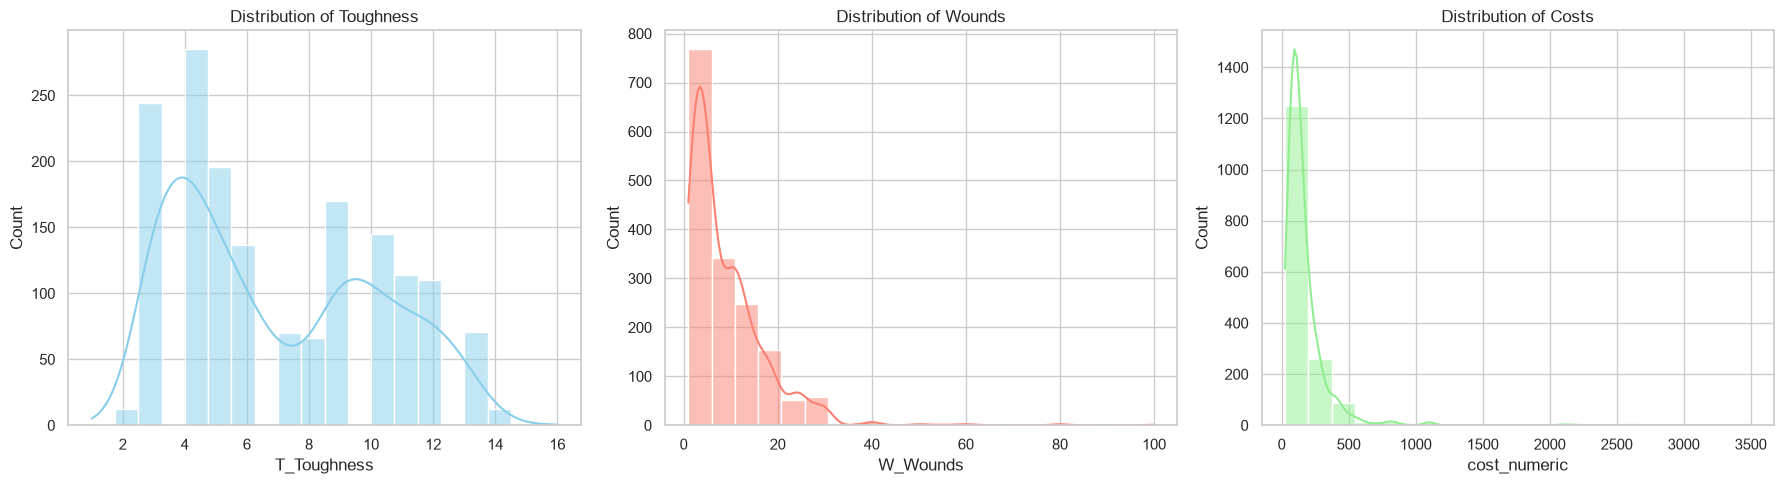

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data['T_Toughness'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Toughness')

sns.histplot(data['W_Wounds'], bins=20, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Wounds')

sns.histplot(data['cost_numeric'], bins=20, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Costs')

plt.tight_layout()
plt.show()


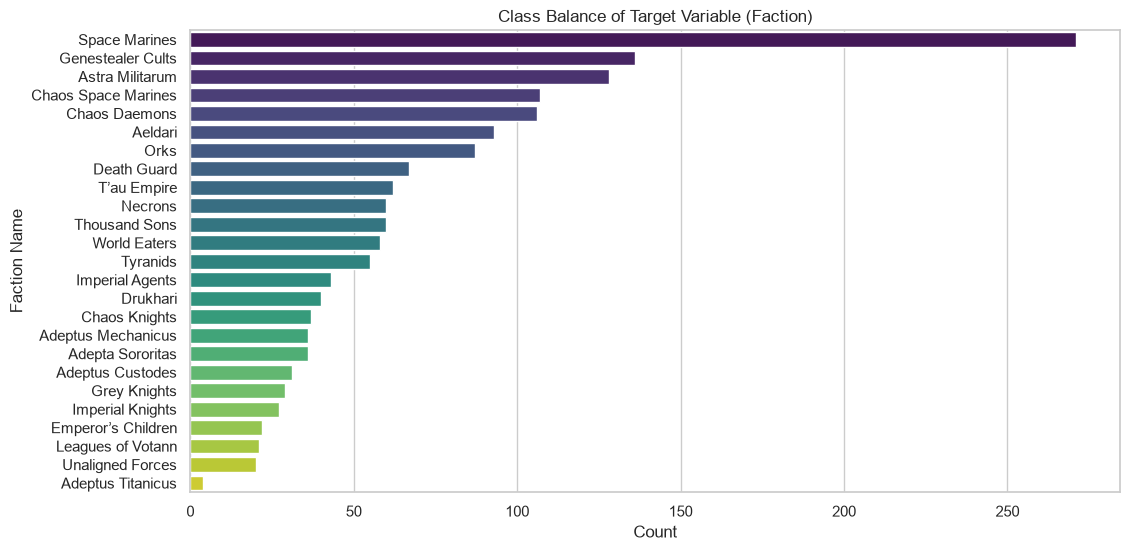

Majority Class Baseline Accuracy: 16.56%


In [6]:
# Target Variable Analysis
plt.figure(figsize=(12, 6))
order = data['faction_name'].value_counts().index
sns.countplot(y=data['faction_name'], order=order, palette='viridis')
plt.title('Class Balance of Target Variable (Faction)')
plt.xlabel('Count')
plt.ylabel('Faction Name')
plt.show()

# Baseline Accuracy
majority_class_count = data['faction_name'].value_counts().max()
baseline = majority_class_count / len(data)
print(f"Majority Class Baseline Accuracy: {baseline*100:.2f}%")


### Target Analysis Conclusions
- The target variable is severely **imbalanced**. Space Marines represent a massive portion of the dataset, which is expected given the tabletop game's lore and rules. 
- A naive baseline simply guessing "Space Marines" would achieve around 15-20% accuracy. Our predictive model must beat this. Data balancing techniques (SMOTE, class weights) will be necessary during modeling.


## 4. Bivariate & Multivariate Analysis
We will analyze how numerical features correlate with each other and how they differ across factions.


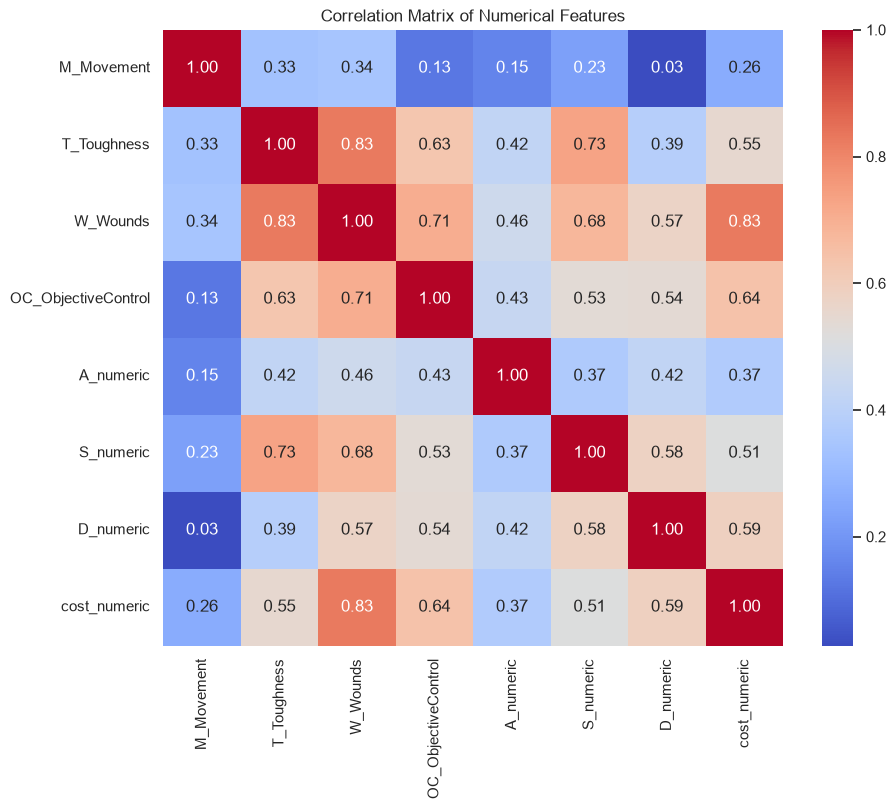

In [7]:
# Correlation Heatmap
numeric_cols = ['M_Movement', 'T_Toughness', 'W_Wounds', 'OC_ObjectiveControl', 'A_numeric', 'S_numeric', 'D_numeric', 'cost_numeric']

plt.figure(figsize=(10, 8))
corr = data[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()


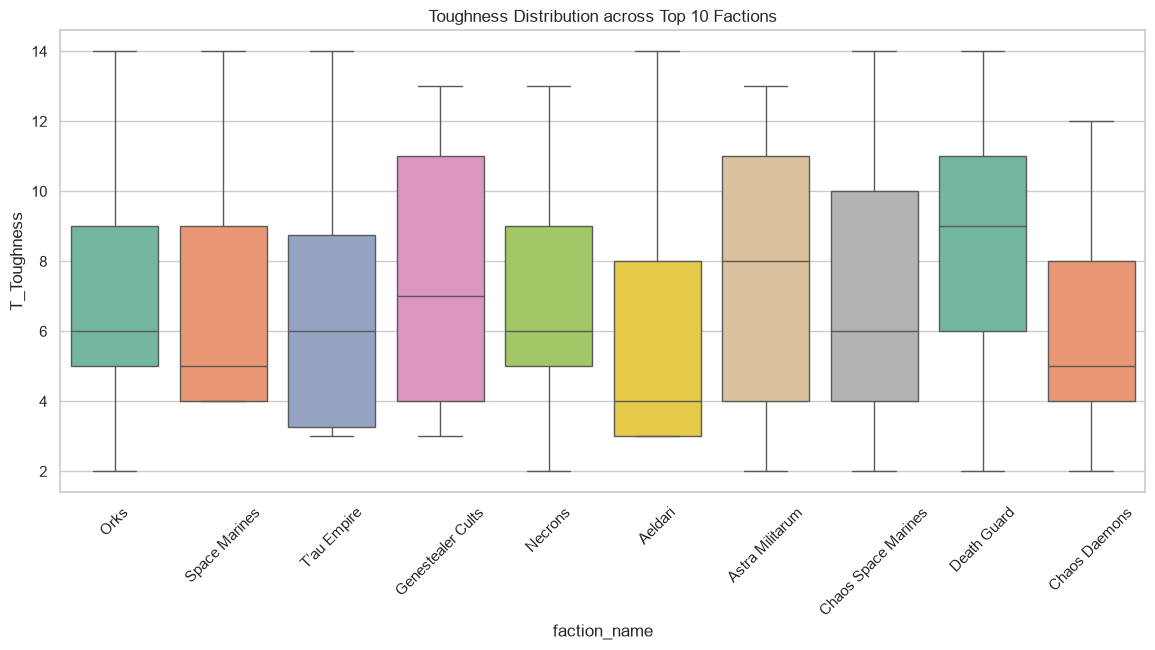

In [8]:
# Boxplot: Toughness by Faction
top_factions = data['faction_name'].value_counts().head(10).index
subset = data[data['faction_name'].isin(top_factions)]

plt.figure(figsize=(14, 6))
sns.boxplot(x='faction_name', y='T_Toughness', data=subset, palette='Set2')
plt.title('Toughness Distribution across Top 10 Factions')
plt.xticks(rotation=45)
plt.show()


### Feature Relationships
- `Toughness` and `Wounds` are highly correlated, which logically represents the "bulk" of a unit.
- Cost strongly correlates with Wounds and Offensive stats, showing the point balancing of the game.
- Boxplots show significant differences between factions: Adeptus Custodes generally exhibit higher toughness compared to Astra Militarum.


## 5. Exploratory Feature Engineering
### Derived Numerical Feature: Offensive Power
We can define theoretical offensive power as $Attacks \times Strength \times Damage$.


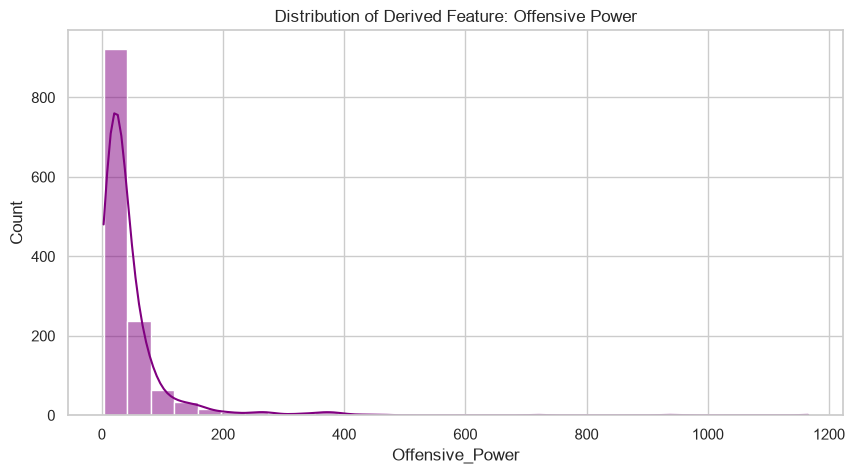

In [9]:
data['Offensive_Power'] = data['A_numeric'] * data['S_numeric'] * data['D_numeric']

plt.figure(figsize=(10, 5))
sns.histplot(data['Offensive_Power'], bins=30, kde=True, color='purple')
plt.title("Distribution of Derived Feature: Offensive Power")
plt.show()


### Text Feature Engineering: Faction Vocabulary
Factions in Warhammer 40k have highly distinct naming conventions. Orks use words like "Kustom" or "Choppa", while Space Marines use "Plasma" or "Bolter". We will extract these text patterns using NLP.


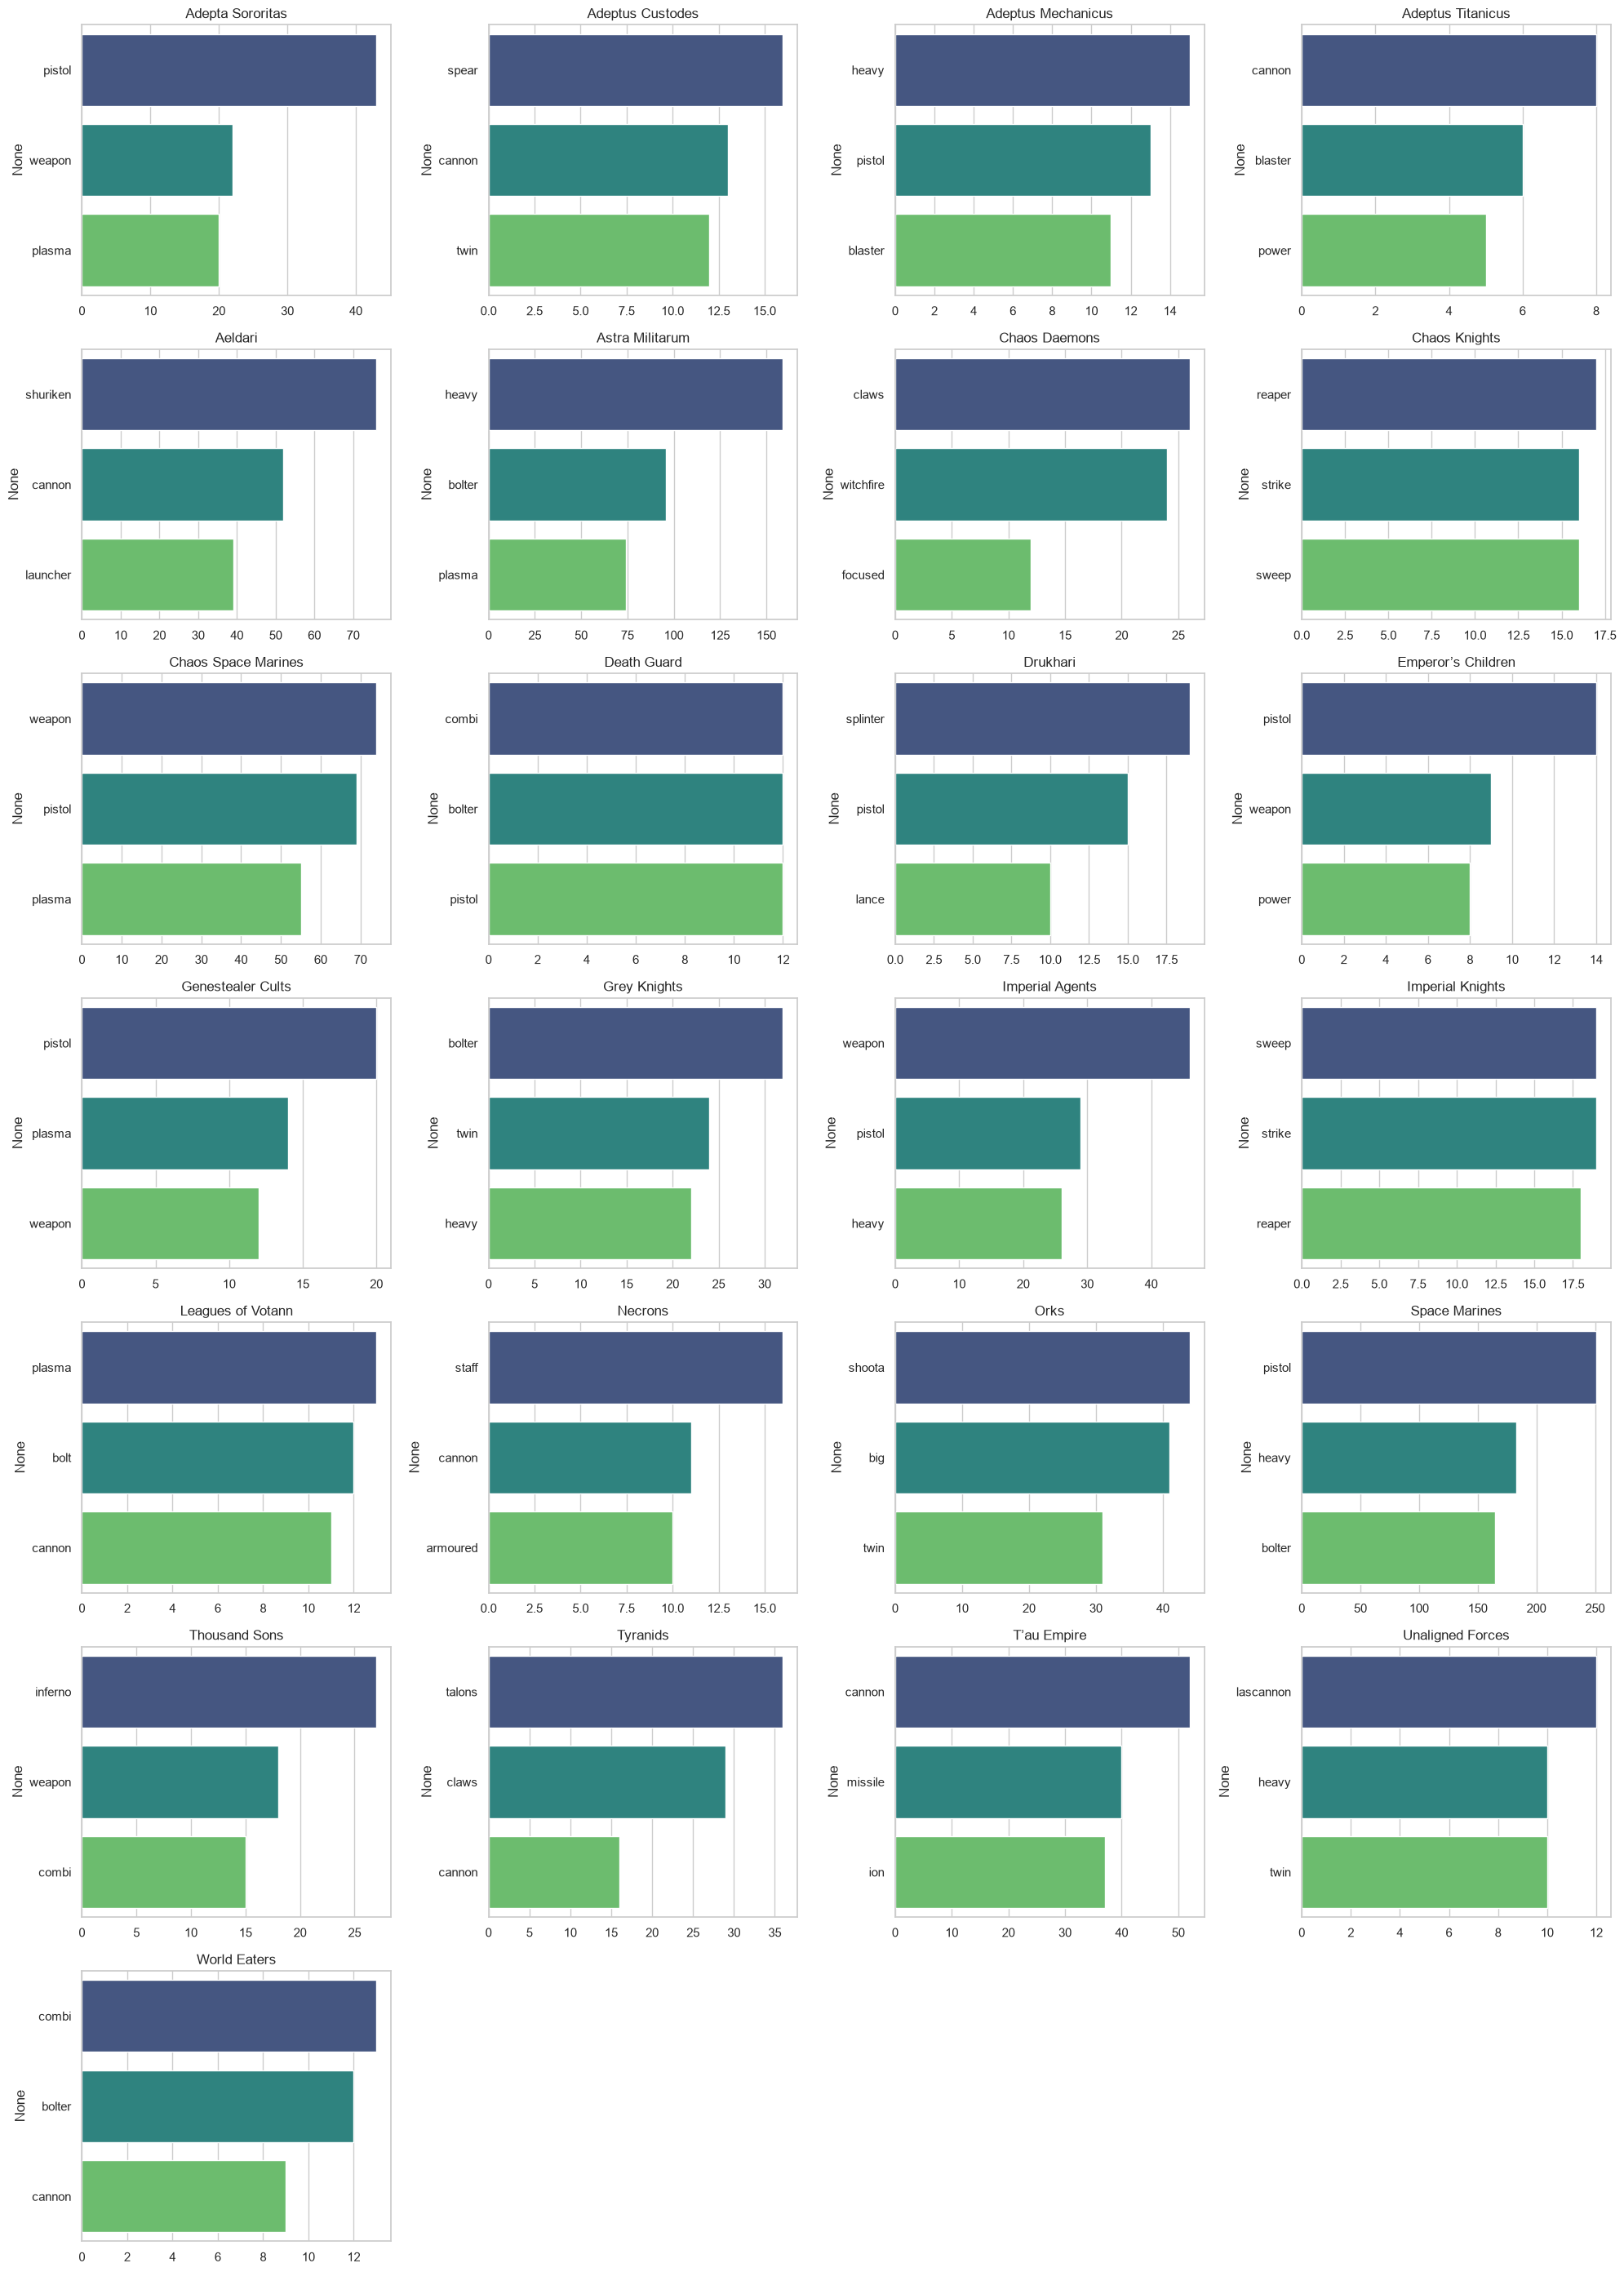

In [10]:
# NLP on Weapon Names for ALL Factions
data['weapon_name'] = data['weapon_name'].fillna('')

# Increase max_features to capture variety across all factions
cv = CountVectorizer(stop_words='english', max_features=100)
words_matrix = cv.fit_transform(data['weapon_name'])
word_counts = pd.DataFrame(words_matrix.toarray(), columns=cv.get_feature_names_out())
word_counts['faction_name'] = data['faction_name']

# Group by faction and get the sum of word counts
faction_words = word_counts.groupby('faction_name').sum()

# Plotting top 3 words for each faction
factions_list = faction_words.index.tolist()
num_factions = len(factions_list)
cols = 4
rows = (num_factions // cols) + (1 if num_factions % cols > 0 else 0)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, faction in enumerate(factions_list):
    row = faction_words.loc[faction]
    top_words = row.sort_values(ascending=False).head(3)
    # Only plot if there are words (count > 0)
    top_words = top_words[top_words > 0]
    
    if not top_words.empty:
        sns.barplot(x=top_words.values, y=top_words.index, ax=axes[i], palette="viridis")
        axes[i].set_title(f'{faction[:25]}')
        axes[i].set_xlabel('')
    else:
        axes[i].set_title(f'{faction[:25]} (No words)')
        axes[i].axis('off')

# Hide any unused subplots
for j in range(len(factions_list), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


The NLP extraction proves highly successful. Words strongly associate with `faction_id`, making text features extremely valuable for prediction.


## 6. Conclusions, Limitations & Roadmap

### Summary of Findings
- **Data Completeness**: Aggregating models and wargear into the datasheets table proved effective, though some descriptive fields contain nulls due to missing sub-components.
- **Strong Predictors**: Both numerical stats (like Toughness distributions) and text features (weapon vocabulary) are powerful discriminators of factions.
- **Class Imbalance**: The dataset is heavily skewed towards Space Marines.

### Limitations
- Our numerical extraction for Attacks and Damage ignored complex dice rolls (e.g., "D6+1"). A more robust parser will be needed to capture true variability.
- Weapon and Model data were averaged per datasheet, which might dilute specialized model roles within mixed units.

### Roadmap for Modeling
1. **Data Cleaning**: Impute missing numerical values using median imputation by faction.
2. **Text Processing**: Apply `TfidfVectorizer` to the `loadout` and `weapon_name` columns to generate robust NLP features for modeling.
3. **Handling Imbalance**: Utilize class weights or oversampling techniques like SMOTE before training.
4. **Algorithm Selection**: Given the mix of dense numerical data and sparse NLP features, algorithms like Random Forest or XGBoost, potentially combined with linear text models, will be evaluated.
